**Scrapping Data**

Scrapping merupakan teknik mengumpulkan data pada sebuah website dengan memasukkan Uniform Resource Locator (URL). Untuk penerapannya pada data youtube, scrapping menggunakan automation program dan menggunakan Application Programming Interface (API) sebagai jalur komunikasi dalam mendapatkan data. Dengan API kita dapat mengumpulkan data lebih spesifik sesuai dengan link URL yang ada tanpa harus mengetahui element HTML pada sebuah website.

In [ ]:
pip install google-api-python-client pandas

Mengambil komentar youtube

In [ ]:
import pandas as pd
from googleapiclient.discovery import build

# API Key dan Video ID
api_key = ""
video_id = ""

# Inisialisasi API YouTube
youtube = build("youtube", "v3", developerKey=api_key)

# Fungsi untuk mendapatkan komentar
def get_comments(video_id):
    comments = []
    request = youtube.commentThreads().list(
        part="snippet",
        videoId=video_id,
        maxResults=100,  # maksimum 100 komentar per halaman
        textFormat="plainText"
    )
    while request:
        response = request.execute()

        for item in response["items"]:
            comment = item["snippet"]["topLevelComment"]["snippet"]["textDisplay"]

            # Menyimpan data komentar ke dalam list
            comments.append({
                "comment": comment
            })

        # Mendapatkan halaman berikutnya, jika ada
        request = youtube.commentThreads().list_next(request, response)

    return comments

Menyimpan data dalam format CSV

In [ ]:
# Memanggil fungsi dan mendapatkan data komentar
comments_data = get_comments(video_id)

# Menyimpan data ke dalam file CSV menggunakan Pandas
df = pd.DataFrame(comments_data)
df.to_csv("youtube_naturalisasi_comments.csv", index=False)
print("Data komentar berhasil disimpan dalam file youtube_naturalisasi_comments.csv")

Data komentar berhasil disimpan dalam file youtube_naturalisasi_comments.csv


Filter kalimat komentar

In [ ]:
import pandas as pd

# Baca file CSV
df = pd.read_csv('/content/youtube_naturalisasi_comments.csv')

# Fungsi untuk menghitung jumlah kata
def filter_minimum_kata(komen):
    if isinstance(komen, str):
        return len(komen.split()) >= 5
    return False

# Filter data dengan minimal 5 kata
filtered_df = df[df["comment"].apply(filter_minimum_kata)]

# Simpan hasil ke file baru
output_path = "Filtered_NaturalisasiTimnasTweet.csv"
filtered_df.to_csv(output_path, index=False)

print(f"File hasil filter disimpan di: {output_path}")

File hasil filter disimpan di: Filtered_NaturalisasiTimnasTweet.csv


**Labeling Data**

Pemberian label ini tentu harus disesuaikan dengan tujuan analisis sebelumnya.

Pemberian label dapat dilakukan secara manual (labeling sebagian dan yang termudah)

In [ ]:
import pandas as pd

In [ ]:
# Perlabelan dilakukan secara manual,sehingga menghasilkan file berikut

data = pd.read_csv('/content/sentiment_youtube_naturalisasi_comments.csv')
data

,comment,sentiment_label
0,dari sekian ketua umum pssi saya hanya kagum s...,positif
1,elkan dipanggil dong pak erick,netral
2,salamuaikum bapak erick thohir selamat siyag s...,positif
3,alhamdulillah prosesnya panjang dan pada akhir...,positif
4,juara aff target realistis,positif
...,...,...
1396,ini materi topiknya bagus banget tapi sayang h...,negatif
1397,erick thohir sty dan semua para garuda muda,positif
1398,tolong bung towel jangan dikasih ruang untuk s...,negatif
1399,bagus kerja ketua umum pssi bapak erick thohir...,positif


**Pre-processing Data**

Tahapan preproses data terdiri dari beberapa tahapan sebagai berikut.

            >   Memuat Data

In [ ]:
import pandas as pd

data = pd.read_csv("/content/sentiment_youtube_naturalisasi_comments.csv")
data

,comment,sentiment_label
0,dari sekian ketua umum pssi saya hanya kagum s...,positif
1,elkan dipanggil dong pak erick,netral
2,salamuaikum bapak erick thohir selamat siyag s...,positif
3,alhamdulillah prosesnya panjang dan pada akhir...,positif
4,juara aff target realistis,positif
...,...,...
1396,ini materi topiknya bagus banget tapi sayang h...,negatif
1397,erick thohir sty dan semua para garuda muda,positif
1398,tolong bung towel jangan dikasih ruang untuk s...,negatif
1399,bagus kerja ketua umum pssi bapak erick thohir...,positif


Menghitung jumlah data keseluruhan

In [ ]:
jumlah_data =len(data)
print(f"Jumlah data : {jumlah_data}")

Jumlah data : 1401


1.      Menghapus tanda baca seperti . , ! $( ) * % @ dan Mengubah kata menjadi huruf kecil

In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
corpus = []
for i in range(0, jumlah_data):
    # Corrected line: The third argument is now data['comment'][i]
    data_comment = re.sub('[^a-zA-Z]',' ', data['comment'][i])
    data_comment = data_comment.lower()
    data_comment = data_comment.split()
    ps = PorterStemmer()
    kata_kata = stopwords.words('indonesian')
    data_comment = [ps.stem(kata) for kata in data_comment if not kata in set(kata_kata)]
    data_comment = ' '.join (data_comment)
    corpus.append(data_comment)


2.   Filtering Data

In [ ]:
# Fungsi untuk menghitung jumlah kata
def filter_minimum_kata(komen):
    if isinstance(komen, str):
        return len(komen.split()) >= 5
    return False

# Filter data dengan minimal 5 kata
filtered_df = data[data["comment"].apply(filter_minimum_kata)]

# Simpan hasil ke file baru
output_path = "Filtered_NaturalisasiTimnasTweet.csv"
filtered_df.to_csv(output_path, index=False)

print(f"File hasil filter disimpan di: {output_path}")

File hasil filter disimpan di: Filtered_NaturalisasiTimnasTweet.csv


3.      Stemming dan lemmatization: merubah kata-kata dalam tweet menjadi bentuk standar atau kata dasar

In [ ]:
# Memuat dataset yang telah ter-filter
data_filter = pd.read_csv('/content/Filtered_NaturalisasiTimnasTweet.csv')

In [ ]:
pip install Sastrawi

**Steamming**

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Membuat instance dari StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi untuk melakukan stemming pada teks bahasa Indonesia
def indonesian_lemmatization(comment):
    return stemmer.stem(comment)

**Lemmization**

In [ ]:
# Terapkan lemmatization pada kolom 'comment' DataFrame
data['comment'] = data_filter['comment'].apply(indonesian_lemmatization)

**Stopword: menghapus kata pada tweet yang terkandung di dalam stopwords.**

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import text_to_word_sequence

# Memastikan data stopwords tersedia
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("stopwords")
nltk.download("words")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [ ]:
data["comment"] = data["comment"].astype(str)

In [ ]:
words = data["comment"].apply(lambda x: text_to_word_sequence(x))

In [ ]:
stop_words = set(stopwords.words("indonesian"))
filtered_words = words.apply(lambda x: [word for word in x if word not in stop_words])
data["comment"] = filtered_words.apply(lambda x: " ".join(x))

**Tokenization: proses untuk membagi teks yang dapat berupa kalimat, paragraf atau dokumen menjadi token-token/kata-kata.**

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

In [ ]:
# Pastikan kolom 'comment' tidak memiliki NaN dan tipe data string
data["comment"] = data["comment"].fillna("").astype(str)

In [ ]:
#buat data sebelum tokenizing

import pandas as pd

# Load the dataset
data = pd.read_csv("/content/Filtered_NaturalisasiTimnasTweet.csv")

# Display the data before tokenization
print("Data Sebelum di tokenize:")
print(data.head(10))

Data Sebelum di tokenize:
                                             comment sentiment_label
0  dari sekian ketua umum pssi saya hanya kagum s...         positif
1                     elkan dipanggil dong pak erick          netral
2  salamuaikum bapak erick thohir selamat siyag s...         positif
3  alhamdulillah prosesnya panjang dan pada akhir...         positif
4  sty sudah natulisasi sampai sekarang kayaknya ...         negatif
5  salah besar bung erick thohir angkat sty jadi ...         negatif
6            kot host motong terus ganti saja anjing         negatif
7                 yes talent ada dan kerja keras oke         positif
8  mengapa timnas selalu di zalim wasit baik di a...         negatif
9  beda level pak erick jauh lebih hebat dan niat...         positif


In [ ]:
print("Data setelah Tokenizing:")
print(words[0:20])

Data setelah Tokenizing:
0     [dari, sekian, ketua, umum, pssi, saya, hanya,...
1                    [elkan, panggil, dong, pak, erick]
2     [salamuaikum, bapak, erick, thohir, selamat, s...
3     [alhamdulillah, proses, panjang, dan, pada, ak...
4     [sty, sudah, natulisasi, sampai, sekarang, kay...
5     [salah, besar, bung, erick, thohir, angkat, st...
6       [kot, host, motong, terus, ganti, saja, anjing]
7            [yes, talent, ada, dan, kerja, keras, oke]
8     [mengapa, timnas, selalu, di, zalim, wasit, ba...
9     [beda, level, pak, erick, jauh, lebih, hebat, ...
10    [erick, thohir, harus, protes, wasit, indonesi...
11               [erick, thohir, baik, dari, the, baik]
12    [pak, erick, ini, memang, pikir, dan, kerja, p...
13    [rossi, enggak, enak, banget, kalo, jadi, host...
14    [hostnya, motong, topik, melulu, ngubah, topik...
15    [host, nya, enggak, profesional, karena, selal...
16    [pak, erick, adalah, salah, satu, putra, baik,...
17    [tanya, mc, nya, 

In [ ]:
data = pd.read_csv('/content/sentiment_youtube_naturalisasi_comments.csv')

In [ ]:
print("Data setelah Tokenizing:")
print(words[0:10])

Data setelah Tokenizing:
0    [dari, sekian, ketua, umum, pssi, saya, hanya,...
1                   [elkan, panggil, dong, pak, erick]
2    [salamuaikum, bapak, erick, thohir, selamat, s...
3    [alhamdulillah, proses, panjang, dan, pada, ak...
4    [sty, sudah, natulisasi, sampai, sekarang, kay...
5    [salah, besar, bung, erick, thohir, angkat, st...
6      [kot, host, motong, terus, ganti, saja, anjing]
7           [yes, talent, ada, dan, kerja, keras, oke]
8    [mengapa, timnas, selalu, di, zalim, wasit, ba...
9    [beda, level, pak, erick, jauh, lebih, hebat, ...
Name: comment, dtype: object


**Inisisasi TF-ID**

In [ ]:
import re

In [ ]:
from sklearn.model_selection import train_test_split
from nltk.stem.porter import PorterStemmer
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

In [ ]:
corpus = []
for i in range(0, jumlah_data):
    data_comment = re.sub('[^a-zA-Z]',' ', data['comment'][i])
    data_comment = data_comment.lower()
    data_comment = data_comment.split()
    ps = PorterStemmer()
    kata_kata = stopwords.words('indonesian')
    data_comment = [ps.stem(kata) for kata in data_comment if not kata in set(kata_kata)]
    data_comment = ' '.join (data_comment)
    corpus.append(data_comment)

cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = data.iloc[:X.shape[0],  0].values

**Splitting Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data['comment'], data['sentiment_label'],
                                                    test_size=0.2, random_state=42)

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y

array(['dari sekian ketua umum pssi saya hanya kagum sama sosok pak erick thohir dia mah sudah kayak tajir sekarang tugas nya jadi ketua umum benar untuk timnas bukan karena duit yang ada mengeluarkan duit pribadi pasti',
       'elkan dipanggil dong pak erick',
       'salamuaikum bapak erick thohir selamat siyag sayang cantik', ...,
       'tolong bung towel jangan dikasih ruang untuk semua program tv',
       'bagus kerja ketua umum pssi bapak erick thohir bravo',
       'lanjutkan terus pak erick soal naturalisasi pemain diaspora yang berkualitas jangan hiraukan orang yang enggak suka timnas maju orang yang mencari cari kesalahan disaat sekarang masyarakat mengakui kemajuan timnas'],
      dtype=object)

**SMOTE**

     SMOTE digunakan untuk mensintesis data di mana fitur-fiturnya
     bersifat kontinu dan permasalahnya bersifat klasifikasi.
     Karena itu,pada bagian ini kita hanya akan mencoba menggunakan dua
     fitur kontinu dengan target klasifikasi.

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [ ]:
pip install -U imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(data["comment"])
y = data["sentiment_label"]

In [ ]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

        Algoritma yang digunakan

In [ ]:
models = {
    "SVC": SVC(kernel='linear', random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [ ]:
# Perulangan untuk melatih dan membuat prediksi
predictions = {}
for model_name, model in models.items():
    # Latih model
    model.fit(X_train_smote, y_train_smote)
    # Simpan prediksi
    predictions[model_name] = model.predict(X_test_tfidf)

    Visualisasi evaluasi dari masing-masing algortima

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

evaluasi = {}
for nama, model in models.items():
    model.fit(X_train_tfidf,y_train)
    # Use X_test_tfidf instead of X_test for prediction
    y_pred = model.predict(X_test_tfidf)

    evaluasi[nama]={
        'prediksi' : y_pred,
        'nilai_true' : y_test,
        'confusion_matrix' :confusion_matrix (y_test,y_pred),
        'akurasi' : accuracy_score (y_test,y_pred),
        'presisi' : precision_score (y_test,y_pred, average='weighted'),
        'recall' : recall_score (y_test,y_pred, average='weighted'),
        'f1' : f1_score (y_test,y_pred, average='weighted')         \
    }

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Membuat Visual Diagram Pada Banyak Model Algoritma
import matplotlib.pyplot as plt

def visual(nama, hasil):
    print("\n")
    print(f"\nNama Model : {nama}")
    print(f"Confusion_matrix")
    print(hasil['confusion_matrix'])
    print(f"\nAccuracy : {hasil['akurasi']:.3f}")
    print(f"Precision : {hasil['presisi']:.3f}")
    print(f"Recall : {hasil['recall']:.3f}")
    print(f"f1 Score : {hasil['f1']:.3f}\n")

    label = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    nilai = [hasil['akurasi'],hasil['presisi'],hasil['recall'],hasil['f1']]

    for index, value in enumerate(nilai):
        plt.text(value,index,str("{:.3f}").format(value))

    plt.barh(label,nilai)
    plt.title(f"Evaluasi Model : {nama}")
    plt.show()




Nama Model : SVC
Confusion_matrix
[[107   0  14]
 [  7   1   8]
 [ 12   0 132]]

Accuracy : 0.854
Precision : 0.862
Recall : 0.854
f1 Score : 0.834



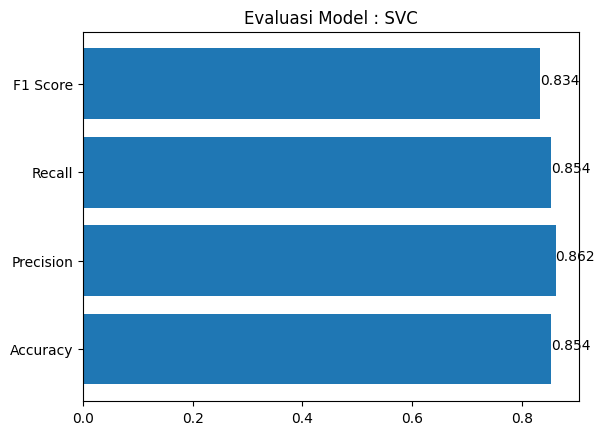




Nama Model : Naive Bayes
Confusion_matrix
[[ 99   0  22]
 [  6   0  10]
 [  7   0 137]]

Accuracy : 0.840
Precision : 0.796
Recall : 0.840
f1 Score : 0.815



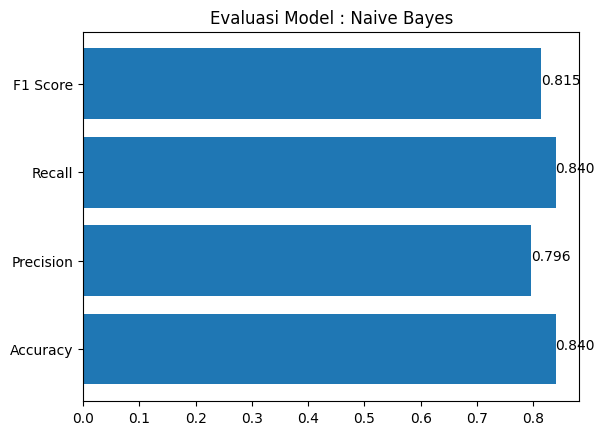




Nama Model : Logistic Regression
Confusion_matrix
[[104   0  17]
 [  8   0   8]
 [ 15   0 129]]

Accuracy : 0.829
Precision : 0.782
Recall : 0.829
f1 Score : 0.805



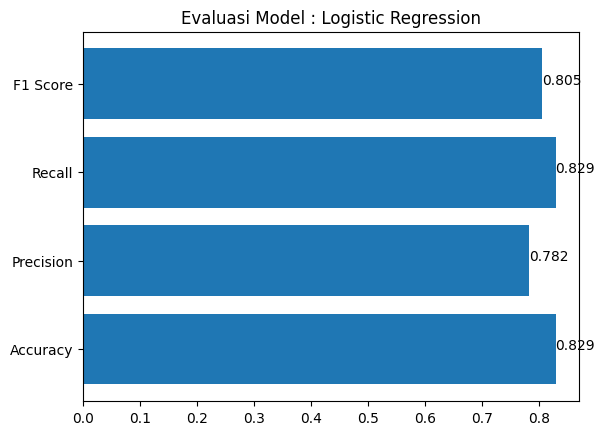




Nama Model : Random Forest
Confusion_matrix
[[104   0  17]
 [ 10   0   6]
 [ 16   0 128]]

Accuracy : 0.826
Precision : 0.779
Recall : 0.826
f1 Score : 0.802



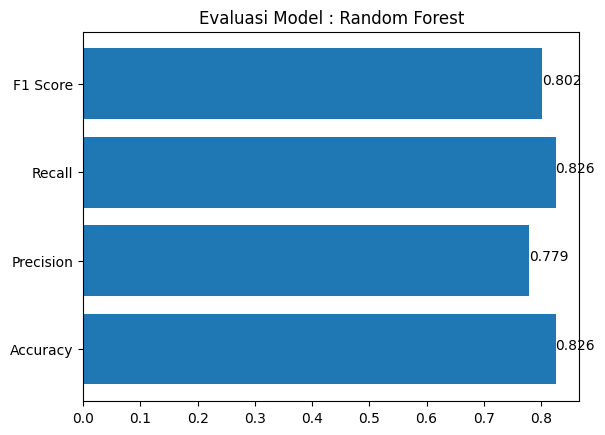




Nama Model : KNN
Confusion_matrix
[[108   2  11]
 [  7   1   8]
 [ 17   2 125]]

Accuracy : 0.833
Precision : 0.809
Recall : 0.833
f1 Score : 0.818



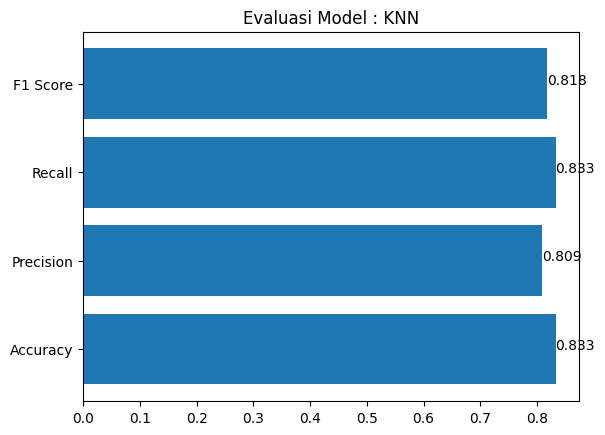

In [ ]:
#Membuat Visual Diagram Pada Banyak Model Algoritma
for nama, hasil in evaluasi.items():
    visual(nama, hasil)

**Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Fungsi untuk cross-validation
def perform_cross_validation(models, X, y, cv=5):
    results = {}
    for model_name, model in models.items():
        print(f"Melakukan Cross-Validation untuk {model_name}...")
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        results[model_name] = scores
        print(f"Accuracy per fold: {scores}")
        print(f"Mean Accuracy: {np.mean(scores):.4f}")
        print(f"Standard Deviation: {np.std(scores):.4f}\n")
    return results

# Lakukan Cross-Validation
cv_results = perform_cross_validation(models, X_tfidf, y, cv=5)

Melakukan Cross-Validation untuk SVC...
Accuracy per fold: [0.85409253 0.82142857 0.79642857 0.83214286 0.80357143]
Mean Accuracy: 0.8215
Standard Deviation: 0.0206

Melakukan Cross-Validation untuk Naive Bayes...
Accuracy per fold: [0.82206406 0.81785714 0.8        0.82142857 0.81785714]
Mean Accuracy: 0.8158
Standard Deviation: 0.0081

Melakukan Cross-Validation untuk Logistic Regression...
Accuracy per fold: [0.84341637 0.81428571 0.78214286 0.82857143 0.8       ]
Mean Accuracy: 0.8137
Standard Deviation: 0.0214

Melakukan Cross-Validation untuk Random Forest...
Accuracy per fold: [0.82918149 0.81785714 0.77142857 0.81071429 0.80357143]
Mean Accuracy: 0.8066
Standard Deviation: 0.0195

Melakukan Cross-Validation untuk KNN...
Accuracy per fold: [0.83629893 0.80357143 0.79285714 0.78571429 0.80714286]
Mean Accuracy: 0.8051
Standard Deviation: 0.0174



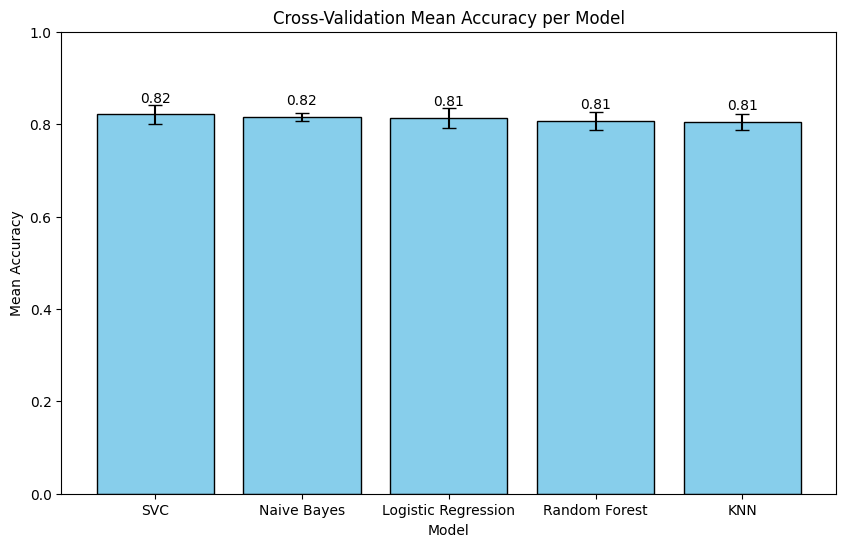

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fungsi untuk visualisasi hasil cross-validation
def plot_cross_validation_results(cv_results):
    # Mengambil mean dan standard deviation dari setiap model
    mean_scores = [np.mean(scores) for scores in cv_results.values()]
    std_scores = [np.std(scores) for scores in cv_results.values()]
    model_names = list(cv_results.keys())

    # Membuat bar chart untuk mean accuracy
    plt.figure(figsize=(10, 6))
    bars = plt.bar(model_names, mean_scores, yerr=std_scores, capsize=5, color='skyblue', edgecolor='black')

    # Menambahkan label dan judul
    plt.title("Cross-Validation Mean Accuracy per Model")
    plt.xlabel("Model")
    plt.ylabel("Mean Accuracy")
    plt.ylim(0, 1)

    # Menambahkan nilai di atas bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

    # Menampilkan grafik
    plt.show()

# Visualisasi hasil cross-validation
plot_cross_validation_results(cv_results)

**Ensemble**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Membuat data training dan testing untuk ensemble
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Mengumpulkan prediksi dari setiap model
ensemble_features_train = []
ensemble_features_test = []

for model_name, model in models.items():
    # Melatih ulang model pada data training
    model.fit(X_train, y_train)

    train_preds = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_train)
    test_preds = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)

    # ubah label prediksi menjadi numerik (0 untuk 'negatif', 1 untuk 'positif')
    if not hasattr(model, "predict_proba"):
        train_preds = [1 if pred == 'positif' else 0 for pred in train_preds]
        test_preds = [1 if pred == 'positif' else 0 for pred in test_preds]

    ensemble_features_train.append(train_preds)
    ensemble_features_test.append(test_preds)

# Membuat matriks ensemble
X_train_ensemble = np.array(ensemble_features_train).T
X_test_ensemble = np.array(ensemble_features_test).T

# Ensemble dengan Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_ensemble, y_train)

# Evaluasi pada data testing
y_pred = gbc.predict(X_test_ensemble)

# Confusion Matrix dan Classification Report
print("Confusion Matrix (Ensemble GBC):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report (Ensemble GBC):")
print(classification_report(y_test, y_pred))

Confusion Matrix (Ensemble GBC):
[[107   0  14]
 [  7   1   8]
 [ 12   0 132]]

Classification Report (Ensemble GBC):
              precision    recall  f1-score   support

     negatif       0.85      0.88      0.87       121
      netral       1.00      0.06      0.12        16
     positif       0.86      0.92      0.89       144

    accuracy                           0.85       281
   macro avg       0.90      0.62      0.62       281
weighted avg       0.86      0.85      0.83       281



**Save Model**

In [ ]:
import pickle
import os

# Direktori untuk menyimpan model
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Menyimpan setiap model dalam format pickle
for model_name, model in models.items():
    model_path = os.path.join(model_dir, f"{model_name.replace(' ', '_').lower()}_model.pkl")
    with open(model_path, "wb") as file:
        pickle.dump(model, file)
    print(f"Model {model_name} berhasil disimpan ke file: {model_path}")

Model SVC berhasil disimpan ke file: saved_models/svc_model.pkl
Model Naive Bayes berhasil disimpan ke file: saved_models/naive_bayes_model.pkl
Model Logistic Regression berhasil disimpan ke file: saved_models/logistic_regression_model.pkl
Model Random Forest berhasil disimpan ke file: saved_models/random_forest_model.pkl
Model KNN berhasil disimpan ke file: saved_models/knn_model.pkl


**Analisa Data**

    Distribusi Label Sentimen

    Menggambarkan seberapa banyak data yang memiliki sentimen positif vs. negatif. Ini penting untuk mengetahui apakah dataset seimbang atau ada masalah imbalanced class.

<ipython-input-48-a4ca2fd305eb>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=data, palette="coolwarm")


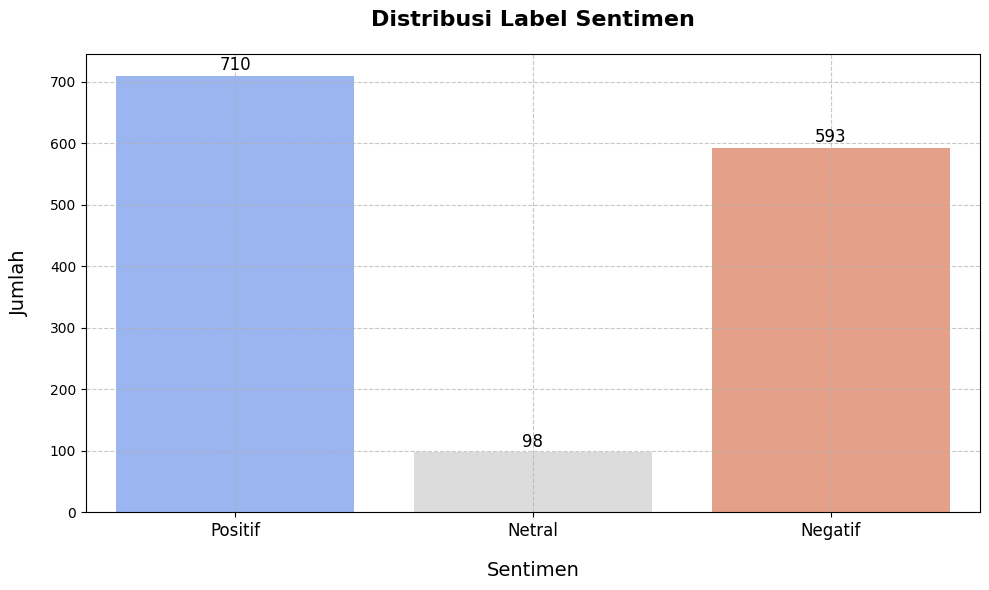

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Menampilkan distribusi label sentimen dengan tampilan yang lebih estetis
plt.figure(figsize=(10, 6))

# Membuat countplot dengan warna yang lebih menarik
sns.countplot(x='sentiment_label', data=data, palette="coolwarm")

# Menambahkan judul dan label
plt.title("Distribusi Label Sentimen", fontsize=16, weight='bold', pad=20)
plt.xlabel("Sentimen", fontsize=14, labelpad=15)
plt.ylabel("Jumlah", fontsize=14, labelpad=15)

# Menambahkan label yang lebih jelas untuk sumbu X
plt.xticks([0, 1, 2], ["Positif", "Netral", "Negatif"], fontsize=12)

# Menambahkan grid untuk memudahkan pembacaan
plt.grid(True, linestyle='--', alpha=0.7)

# Menambahkan nilai di atas setiap bar untuk menunjukkan jumlahnya
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2., p.get_height() + 2,
             f'{int(p.get_height())}', ha='center', va='bottom', fontsize=12)

# Menampilkan grafik
plt.tight_layout()
plt.show()


    Panjang Teks rata-rata

In [ ]:
# Menambahkan kolom panjang teks
data['text_length'] = data['comment'].apply(len)

# Menampilkan statistik panjang teks
print("Statistik Panjang Teks:")
print(data['text_length'].describe())

Statistik Panjang Teks:
count    1401.000000
mean      112.384011
std       133.006395
min        12.000000
25%        43.000000
50%        78.000000
75%       136.000000
max      2219.000000
Name: text_length, dtype: float64


    Kata Paling Sering Muncul

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Menggunakan CountVectorizer untuk mengekstrak kata-kata
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(data['comment'])

# Menampilkan kata-kata paling sering muncul
features = vectorizer.get_feature_names_out()
word_count = X.toarray().sum(axis=0)
word_freq = dict(zip(features, word_count))

# Menampilkan 10 kata yang paling sering muncul
sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
print("10 Kata Paling Sering Muncul:")
for word, freq in sorted_word_freq[:10]:
    print(f"{word}: {freq}")

10 Kata Paling Sering Muncul:
erick: 728
pak: 657
yang: 568
dan: 453
di: 430
indonesia: 317
pssi: 267
thohir: 260
timnas: 253
enggak: 239


    Visualisasi Distribusi Sentimen

<ipython-input-51-f8325e6e8231>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=data, palette="coolwarm")


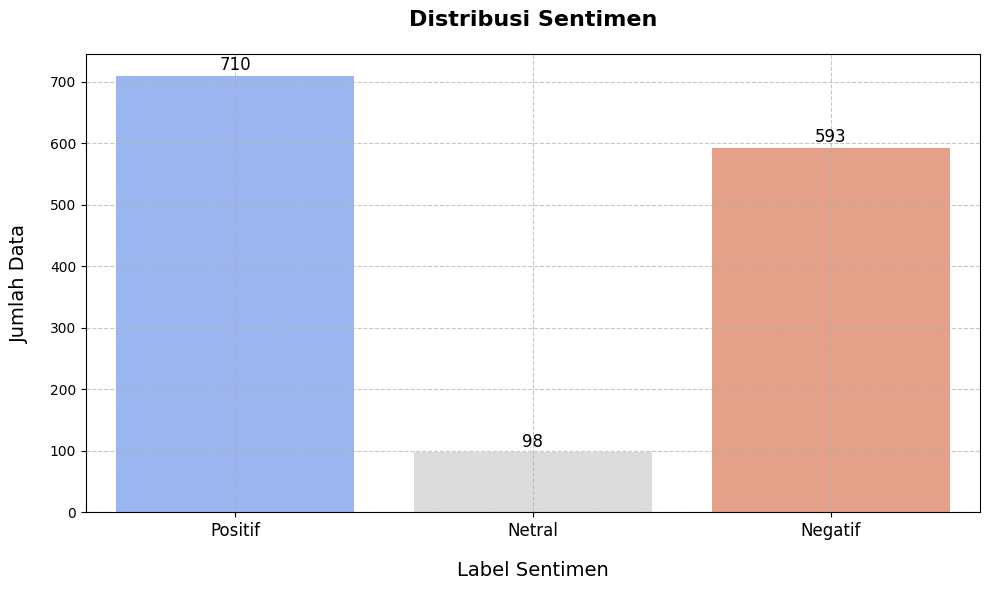

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Menampilkan distribusi label sentimen dengan tampilan yang lebih estetis
plt.figure(figsize=(10, 6))

# Membuat countplot dengan warna yang lebih menarik
sns.countplot(x='sentiment_label', data=data, palette="coolwarm")

# Menambahkan judul dan label dengan font yang lebih besar dan jelas
plt.title("Distribusi Sentimen", fontsize=16, weight='bold', pad=20)
plt.xlabel("Label Sentimen", fontsize=14, labelpad=15)
plt.ylabel("Jumlah Data", fontsize=14, labelpad=15)

# Menambahkan label yang lebih jelas untuk sumbu X
plt.xticks([0, 1, 2], ["Positif", "Netral", "Negatif"], fontsize=12)

# Menambahkan grid untuk memudahkan pembacaan
plt.grid(True, linestyle='--', alpha=0.7)

# Menambahkan nilai di atas setiap bar untuk menunjukkan jumlahnya
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2., p.get_height() + 2,
             f'{int(p.get_height())}', ha='center', va='bottom', fontsize=12)

# Menampilkan grafik
plt.tight_layout()
plt.show()

    Word Cloud

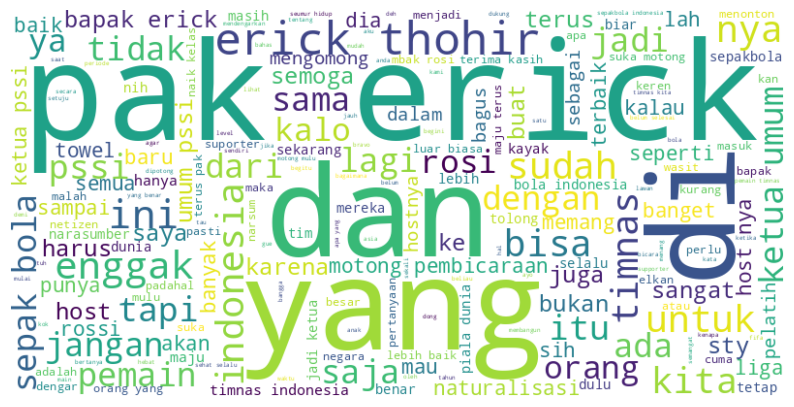

In [ ]:
from wordcloud import WordCloud

# Menggabungkan semua komentar menjadi satu string besar
text = ' '.join(data['comment'])

# Membuat word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Menampilkan word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()